# Detecting cold fronts using day-to-day difference in maximum temperature

In [8]:
import glob
import xarray as xr
import matplotlib.pyplot as plt

In [4]:
pattern = "/g/data/gb02/public/AM3/output/control/n96/am3a.pb*.nc"  
files = glob.glob(pattern)

varname = "fld_s03i236_max"  

ds = xr.open_mfdataset(
    files,
    combine="by_coords",  
)

da = ds[varname]

ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.08/share/proj failed


In [ ]:
da_deltat = da.diff(dim="time")

# Fronts are deltat < -10, count frecuency by year
da_fronts = (da_deltat <= -10).groupby("time.year").sum(dim="time") 
da_fronts

<xarray.DataArray 'fld_s03i236_max' (year: 2, lat: 144, lon: 192)> Size: 442kB
dask.array<transpose, shape=(2, 144, 192), dtype=int64, chunksize=(1, 144, 192), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
  * lat      (lat) float64 1kB -89.38 -88.12 -86.88 -85.62 ... 86.88 88.12 89.38
    height   float64 8B 1.5
  * year     (year) int64 16B 2007 2008

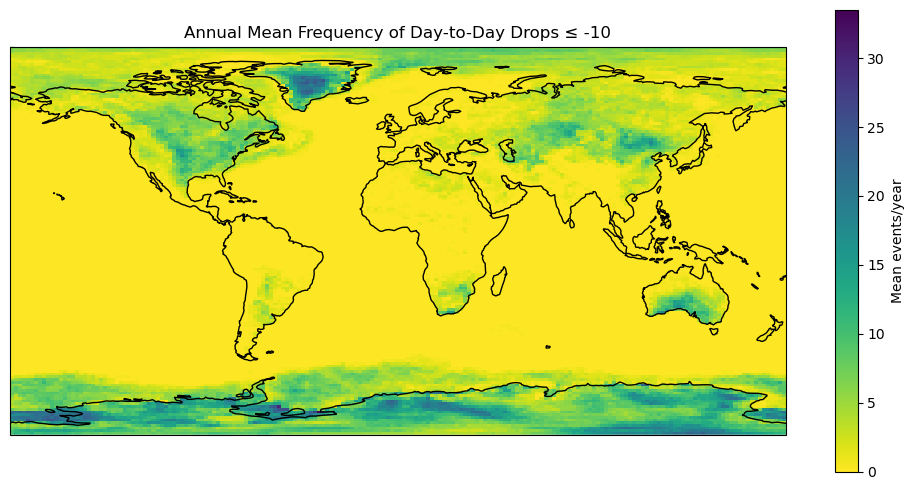

In [ ]:
import cartopy.crs as ccrs

fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={"projection": ccrs.PlateCarree()})
da_fronts.mean(dim="year").plot(
    ax=ax,
    cmap="viridis_r",
    cbar_kwargs={"label": "days/year"},
    transform=ccrs.PlateCarree(),
)
ax.coastlines()
ax.set_title("Annual Mean Frequency of cold fronts (2007-2008)")
plt.tight_layout()
plt.show()